[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Residual Networks: ResNet

Everything in this module so far has pushed in one direction: deeper is better.
LeNet had five layers, AlexNet eight, VGG eleven to nineteen, and each step up
bought accuracy.  Batch normalization then removed the scale problems that made
depth hard to train.  The obvious next move is to keep going.

It does not work.  Past a certain depth, adding layers makes a network *worse* —
and not by overfitting, which would at least make sense.  The **training** error
goes up.  The deeper network fails to fit data that the shallower one fits fine.

That should strike you as impossible, and the argument for why is worth stating
carefully.  Take a network that works, and add ten layers on top of it.  If those
ten layers each computed the identity function, the deeper network would compute
exactly what the shallower one does, and score exactly the same.  So a solution
at least as good as the shallow network's *provably exists* in the deeper
network's parameter space.  Gradient descent simply fails to find it.

This is not a problem about capacity or data.  It is a problem about
optimization, and the fix is one of the most consequential ideas in deep
learning:

> He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image
> recognition. *IEEE Conference on Computer Vision and Pattern Recognition*.

**ResNet** won ImageNet 2015 with 152 layers, roughly eight times VGG's depth, at
a top-5 error of 3.57% — below the commonly quoted figure for human performance
on the task.  More importantly, the idea outlived the architecture.  Residual
connections are in every transformer you have seen; the `x + sublayer(x)` in the
module 04 notebooks is exactly what this notebook is about.

In [1]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG

import time

import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from matplotlib import pyplot as plt

In [2]:
# if you have a GPU we should enable it
# mps is the pytorch device that supports GPU computations on MacOS

device = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Using {device} device')

Using mps device


## Making the identity easy

Here is the reframing that solves it.

A stack of layers computes some function $f(\mathbf{x})$, and we have just argued
that the function we would often like it to compute — or to stay close to — is
the identity, $f(\mathbf{x}) = \mathbf{x}$.  For a stack of convolutions and
ReLUs, that is a surprisingly awkward target.  Nothing about the parameters makes
the identity a natural resting place; the layer has to *construct* it, and a
random initialization is nowhere near.

So change what the layers are asked to produce.  Instead of computing
$f(\mathbf{x})$ directly, let them compute the **residual**
$g(\mathbf{x}) = f(\mathbf{x}) - \mathbf{x}$, and recover the answer by adding
the input back:

$$f(\mathbf{x}) = g(\mathbf{x}) + \mathbf{x}$$

The set of functions the block can express is unchanged — anything you could
write as $f$ you can write as $g + \mathbf{x}$.  What changes is which function
is *easy*.  Now the identity corresponds to $g(\mathbf{x}) = 0$, and zero is what
you get by driving the weights toward zero, which is precisely what weight decay
does and what small initialization starts near.  The identity has gone from a
target that must be built to the block's default behaviour.

In [ ]:
def residual_block_figure():
    """A plain block beside a residual block: the dashed box is the same in both."""
    from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle, Rectangle

    blue, grey, red = '#dce7f2', '0.45', '#c1440e'
    w, h, dy = 1.52, 0.34, 0.50           # inches
    x_plain, x_res = 0.0, 2.42
    x_skip = x_res + w / 2 + 0.42         # how far right the skip path detours

    ys = [-i * dy for i in range(5)]      # conv, bn, relu, conv, bn
    y_join = -2.50                        # the +, in the residual block
    y_relu = -3.05                        # the final ReLU, aligned in both
    y_out = -3.58

    fig, ax = plt.subplots()

    def box(xc, yc, label):
        ax.add_patch(FancyBboxPatch((xc - w / 2, yc - h / 2), w, h,
                                    boxstyle='round,pad=0.012,rounding_size=0.04',
                                    linewidth=0.9, edgecolor='0.4',
                                    facecolor=blue, zorder=4))
        ax.text(xc, yc, label, ha='center', va='center', fontsize=7.6, zorder=5)

    def down(xc, y0, y1, color=grey, lw=0.9):
        ax.add_patch(FancyArrowPatch((xc, y0), (xc, y1), arrowstyle='-|>',
                                     mutation_scale=7, linewidth=lw, color=color,
                                     shrinkA=0, shrinkB=0, zorder=2))

    for xc, residual in ((x_plain, False), (x_res, True)):
        ax.text(xc, 0.62, r'$\mathbf{x}$', ha='center', va='center', fontsize=11)
        down(xc, 0.46, ys[0] + h / 2)
        for y, label in zip(ys, ['3x3 convolution', 'batch norm', 'ReLU',
                                 '3x3 convolution', 'batch norm']):
            box(xc, y, label)
        for y0, y1 in zip(ys[:-1], ys[1:]):
            down(xc, y0 - h / 2, y1 + h / 2)

        # the dashed box covers the weight layers only, in both panels
        dash_lo = ys[-1] - h / 2 - 0.10
        ax.add_patch(Rectangle((xc - w / 2 - 0.11, dash_lo), w + 0.22,
                               (h / 2 + 0.10) - dash_lo, facecolor='none',
                               edgecolor='0.55', linewidth=0.85,
                               linestyle=(0, (4, 3)), zorder=1))
        label = (r'learns $g(\mathbf{x}) = f(\mathbf{x}) - \mathbf{x}$' if residual
                 else r'must learn $f(\mathbf{x})$')
        ax.text(xc - w / 2 - 0.22, (h / 2 + dash_lo) / 2, label, rotation=90,
                ha='center', va='center', fontsize=7.2, color='0.4')

        if residual:
            down(xc, ys[-1] - h / 2, y_join + 0.13)
            ax.add_patch(Circle((xc, y_join), 0.125, facecolor='white',
                                edgecolor='0.4', linewidth=0.9, zorder=5))
            ax.text(xc, y_join, '+', ha='center', va='center', fontsize=10, zorder=6)
            ax.plot([xc, x_skip], [0.30, 0.30], color=red, linewidth=1.5, zorder=3,
                    solid_capstyle='round')
            ax.plot([x_skip, x_skip], [0.30, y_join], color=red, linewidth=1.5,
                    zorder=3, solid_capstyle='round')
            ax.add_patch(FancyArrowPatch((x_skip, y_join), (xc + 0.14, y_join),
                                         arrowstyle='-|>', mutation_scale=8,
                                         linewidth=1.5, color=red, shrinkA=0,
                                         shrinkB=0, zorder=3))
            ax.text(x_skip + 0.10, (0.30 + y_join) / 2, r'$\mathbf{x}$', color=red,
                    fontsize=10, ha='left', va='center')
            down(xc, y_join - 0.13, y_relu + h / 2)
            out = r'$\mathrm{ReLU}(g(\mathbf{x}) + \mathbf{x})$'
        else:
            down(xc, ys[-1] - h / 2, y_relu + h / 2)
            out = r'$\mathrm{ReLU}(f(\mathbf{x}))$'
        box(xc, y_relu, 'ReLU')
        down(xc, y_relu - h / 2, y_out + 0.04)
        ax.text(xc, y_out - 0.15, out, ha='center', va='center', fontsize=8.6)

    ax.text(x_plain, 1.02, 'a plain block', ha='center', va='center',
            fontsize=9.5, fontweight='bold')
    ax.text(x_res, 1.02, 'a residual block', ha='center', va='center',
            fontsize=9.5, fontweight='bold')

    lo, hi = -1.12, x_skip + 0.34
    y_lo, y_hi = y_out - 0.42, 1.30
    ax.set_xlim(lo, hi); ax.set_ylim(y_lo, y_hi); ax.axis('off')
    fig.set_size_inches(hi - lo, y_hi - y_lo)
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

residual_block_figure()

That solid line carrying $\mathbf{x}$ around the layers is a **residual
connection**, or a skip connection.  There is a second way to read it that is
just as important: during backpropagation, the addition sends the gradient down
*both* paths, so every block has a route by which gradient reaches the layers
below it without passing through any weights at all.  Whatever shrinking the
convolutional path does to the gradient, the skip path is there beside it,
undiminished.  In a hundred-layer network that is the difference between a
gradient that survives to the bottom and one that does not.

Two views, one mechanism: forward, it makes the identity cheap; backward, it
gives the gradient a clear path.

### Why the gradient survives

The backward reading deserves to be made precise, because it is the part that
explains a hundred layers.

Write a stack of $L$ blocks, and let $\mathbf{x}_l$ be what enters block $l$.  In
a plain network $\mathbf{x}_{l+1} = f_l(\mathbf{x}_l)$, so the chain rule gives

$$\frac{\partial \mathcal{L}}{\partial \mathbf{x}_0}
= \frac{\partial \mathcal{L}}{\partial \mathbf{x}_L}
  \prod_{l=0}^{L-1} \frac{\partial f_l}{\partial \mathbf{x}_l}.$$

A product of $L$ Jacobians.  If each one scales its input by a typical factor
$\sigma$, the product scales by $\sigma^L$ — exponential in depth.  For
$\sigma = 0.9$ and $L = 50$ that is a factor of about $10^{-3}$; for
$\sigma = 1.1$ it is $10^{2}$ in the other direction.  Nothing holds $\sigma$ at
exactly 1, and initialization can only set it approximately, at the start, before
training moves the weights anywhere it likes.

Now the residual case, $\mathbf{x}_{l+1} = \mathbf{x}_l + g_l(\mathbf{x}_l)$.
Differentiating,

$$\frac{\partial \mathbf{x}_{l+1}}{\partial \mathbf{x}_l}
= \mathbf{I} + \frac{\partial g_l}{\partial \mathbf{x}_l},
\qquad\text{so}\qquad
\frac{\partial \mathcal{L}}{\partial \mathbf{x}_0}
= \frac{\partial \mathcal{L}}{\partial \mathbf{x}_L}
  \prod_{l=0}^{L-1}\!\left(\mathbf{I} + \frac{\partial g_l}{\partial \mathbf{x}_l}\right).$$

Multiply that product out, writing $J_l$ for $\partial g_l / \partial \mathbf{x}_l$:

$$\prod_{l=0}^{L-1}\left(\mathbf{I} + J_l\right)
= \mathbf{I} \;+\; \sum_l J_l \;+\; \sum_{l < m} J_m J_l \;+\; \cdots$$

**The leading term is the identity, and it is there whatever the weights do.**
Every other term contains at least one Jacobian and can shrink toward zero; that
one cannot, because it contains no weights at all.  So the gradient always has a
route from the loss back to block $l$ with gain exactly 1, and the failure mode
changes character.  It is no longer "the signal decays by construction" but "the
signal decays only if the learned terms actively cancel it".  When the $J_l$ are
small — which weight decay encourages, and which the $\boldsymbol{\gamma} = 0$
trick enforces exactly at initialization — the product sits close to $\mathbf{I}$
and the gradient arrives essentially undiminished.

One honesty note.  The block we built applies a ReLU *after* the addition, so the
identity path is not quite clean: the gradient still passes through that
nonlinearity once per block.  He and colleagues noticed this and proposed a
rearrangement in which the skip connection is a true identity all the way down:

> He, K., Zhang, X., Ren, S., & Sun, J. (2016). Identity mappings in deep
> residual networks. *European Conference on Computer Vision*.

That variant, with batch normalization and ReLU moved *before* the convolutions,
is what very deep ResNets use — and what a transformer block does.  Exercise 9
asks you to build it.

We can watch the difference directly.  The function below stacks $L$ identical
blocks, pushes one batch through, backpropagates, and records the norm of the
gradient arriving at each block's input.  It uses plain linear layers rather than
convolutions, to isolate the effect of depth from everything else.

In [ ]:
def gradient_by_depth(residual, depth=30, width=64, batch=32, seed=0):
    """Norm of the gradient arriving at the input of each block in a deep stack."""
    torch.manual_seed(seed)
    blocks = nn.ModuleList([nn.Sequential(nn.Linear(width, width), nn.ReLU(),
                                          nn.Linear(width, width))
                            for _ in range(depth)])
    X = torch.randn(batch, width, requires_grad=True)
    entering = []
    for block in blocks:
        X.retain_grad()
        entering.append(X)
        X = X + block(X) if residual else block(X)
    # a random covector, so the top-level gradient is not artificially uniform
    (X * torch.randn_like(X)).sum().backward()
    return [x.grad.norm().item() for x in entering]

plain = gradient_by_depth(residual=False)
skip = gradient_by_depth(residual=True)

print(f'plain stack     top {plain[-1]:9.2e}   bottom {plain[0]:9.2e}')
print(f'residual stack  top {skip[-1]:9.2e}   bottom {skip[0]:9.2e}')

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.semilogy(range(len(plain)), plain, color='C0', marker='o', markersize=3,
            label='plain stack')
ax.semilogy(range(len(skip)), skip, color='C3', marker='s', markersize=3,
            label='residual stack')
ax.set_xlabel('block (0 is closest to the input)')
ax.set_ylabel('norm of the gradient entering the block')
ax.legend()
fig.tight_layout()

Note the logarithmic axis: the plain stack's curve is close to a straight line on
it, and a straight line on a log axis is exponential decay.  Over thirty blocks
the gradient falls by roughly seventeen orders of magnitude, so by the time it
reaches the early layers there is nothing left — add a few more blocks and it
underflows to exactly zero in single precision, at which point those layers stop
training altogether.

The residual stack's curve is nearly flat, and if anything drifts *upward* toward
the input, because each block adds its own contribution to a gradient that is
already passing through undiminished.  That is the $\mathbf{I}$ in the expansion
above, made visible.

## Where `nn.Sequential` runs out

Up to now every network in this module has been a straight line, and
`nn.Sequential` — which simply pipes each layer's output into the next — has been
enough.  A residual block is not a straight line.  Its input goes two places at
once and the results are added, and there is no way to say that as a sequence.

So we write a real `nn.Module` with a `forward` method that describes the graph.
This is what the class-based interface is *for*, and it is worth noticing that we
have got this far without needing it.

In [4]:
class Residual(nn.Module):
    """A residual block: two 3x3 convolutions, with the input added to the output."""
    def __init__(self, num_channels, use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.LazyConv2d(num_channels, kernel_size=3, padding=1,
                                   stride=strides)
        self.bn1 = nn.LazyBatchNorm2d()
        self.conv2 = nn.LazyConv2d(num_channels, kernel_size=3, padding=1)
        self.bn2 = nn.LazyBatchNorm2d()
        # used only when the block changes shape, so that x and g(x) can be added
        self.conv3 = (nn.LazyConv2d(num_channels, kernel_size=1, stride=strides)
                      if use_1x1conv else None)

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))          # g(x)
        if self.conv3:
            X = self.conv3(X)                # reshape the skip path to match
        return F.relu(Y + X)                 # g(x) + x

The convolutional path is the VGG pattern — two $3\times3$ convolutions — with
batch normalization after each, which is where the previous notebook pays off.
The addition happens *before* the final ReLU, so the identity really is available:
with $g(\mathbf{x}) = 0$ the block returns $\mathrm{ReLU}(\mathbf{x})$, and since
$\mathbf{x}$ is itself the output of a ReLU one level down, that is $\mathbf{x}$.

The `conv3` branch handles the one case where plain addition fails. Adding
$\mathbf{x}$ to $g(\mathbf{x})$ requires them to have the same shape, and a block
that halves the resolution or changes the channel count breaks that. When it
does, a $1\times1$ convolution with matching stride — the per-pixel linear map
from notebook 06_04 — reshapes the skip path so the two agree.

Let's check both cases.

In [5]:
X = torch.randn(4, 3, 6, 6)

same = Residual(3)
print('shape preserved:      ', tuple(same(X).shape))

downsample = Residual(6, use_1x1conv=True, strides=2)
print('halved, channels x2:  ', tuple(downsample(X).shape))

shape preserved:       (4, 3, 6, 6)
halved, channels x2:   (4, 6, 3, 3)


## Is the identity really the default?

The claim is that a freshly initialized residual block starts out close to the
identity.  That is testable, so let's test it rather than take it on faith.  We
compare a block's output with its input, and do the same for the convolutional
path on its own.

In [6]:
torch.manual_seed(0)
block = Residual(8)
X = torch.relu(torch.randn(16, 8, 12, 12))   # a plausible post-ReLU activation
block.eval()
with torch.no_grad():
    block(X)                                  # materialize the Lazy layers
    out = block(X)
    residual_path = block.bn2(block.conv2(F.relu(block.bn1(block.conv1(X)))))

def relative_difference(a, b):
    return ((a - b).norm() / b.norm()).item()

print(f'|g(x)| / |x|              {residual_path.norm() / X.norm():.3f}')
print(f'|block(x) - x| / |x|      {relative_difference(out, X):.3f}')
print()
# now drive the residual path to zero, as weight decay would
with torch.no_grad():
    block.bn2.weight.zero_()
    out_zeroed = block(X)
print(f'with the last BN scale set to 0:')
print(f'|block(x) - x| / |x|      {relative_difference(out_zeroed, X):.3f}  <- exactly the identity')

|g(x)| / |x|              0.200
|block(x) - x| / |x|      0.185

with the last BN scale set to 0:
|block(x) - x| / |x|      0.000  <- exactly the identity


At initialization the block is already within shouting distance of the identity,
and setting a single parameter tensor to zero makes it *exactly* the identity.
That is the whole argument in two numbers.

It also suggests a trick that practitioners use: initialize the last batch
normalization of every block with $\boldsymbol{\gamma} = 0$, so the network
*starts* as the identity everywhere and blocks switch themselves on as training
finds a use for them.  A 152-layer network then begins life behaving like a very
shallow one, which is a far better starting point than 152 layers of noise.

## The ResNet-18 architecture

The full network is built from these blocks in a pattern that should look
familiar from VGG:

* a stem: a $7\times7$ stride-2 convolution to 64 channels, batch normalization,
  ReLU, and a $3\times3$ stride-2 max-pool — two quick resolution cuts before the
  expensive part begins;
* four stages of two residual blocks each, where every stage after the first
  halves the resolution and doubles the channels;
* global average pooling and a single linear layer.

Eight residual blocks with two convolutions each, plus the stem convolution and
the final linear layer, gives eighteen layers with parameters: **ResNet-18**.

The last item deserves a pause.  AlexNet and VGG ended with two $4096$-wide dense
layers holding 92% and 93% of all parameters.  ResNet ends with
`nn.AdaptiveAvgPool2d(1)`, which averages each channel's entire feature map down
to a single number, followed by one linear layer to the classes.  For a
512-channel final stage on ten classes that is 5,130 parameters where VGG had 120
million.

This is the fix we have been pointing at since AlexNet, and it is almost
embarrassingly simple.  It also makes architectural sense: a global average is
translation invariant by construction, which is the property we have been
building toward all module, whereas a flatten-then-dense head assigns separate
weights to each spatial position and thereby throws it away.

In [7]:
def resnet_block(num_channels, num_residuals, first_block=False):
    """A stage of residual blocks; all but the first stage halve the resolution."""
    blocks = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blocks.append(Residual(num_channels, use_1x1conv=True, strides=2))
        else:
            blocks.append(Residual(num_channels))
    return nn.Sequential(*blocks)

def make_resnet(arch, num_classes=10):
    """ResNet from a list of (num_residuals, num_channels) pairs, one per stage."""
    stem = nn.Sequential(
        nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3),
        nn.LazyBatchNorm2d(), nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride=2, padding=1))
    stages = [resnet_block(channels, num_residuals, first_block=(i == 0))
              for i, (num_residuals, channels) in enumerate(arch)]
    return nn.Sequential(
        stem, *stages,
        nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
        nn.LazyLinear(num_classes))

resnet_18 = ((2, 64), (2, 128), (2, 256), (2, 512))

Note that the outer structure is a `nn.Sequential` again.  Only the *block* needed
a custom `forward`; once we have it, stacking blocks is a straight line like
everything else.  That is how nearly all modern architectures are organized —
a hand-written module for the one non-sequential piece, composed sequentially.

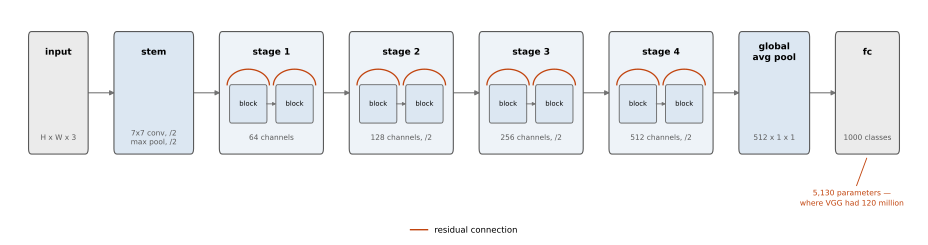

In [8]:
def resnet18_figure(width=13.0):
    """ResNet-18: a stem, four stages of two residual blocks, and almost no head."""
    from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Arc

    scale = width / 13.0
    def pt(size):
        return size * scale
    blue, grey, red, plain = '#dce7f2', '0.45', '#c1440e', '0.92'

    # label, sub-label, width, kind
    items = [
        ('input',   'H x W x 3',        1.30, 'data'),
        ('stem',    '7x7 conv, /2\nmax pool, /2', 1.75, 'plain'),
        ('stage 1', '64 channels',      2.30, 'stage'),
        ('stage 2', '128 channels, /2', 2.30, 'stage'),
        ('stage 3', '256 channels, /2', 2.30, 'stage'),
        ('stage 4', '512 channels, /2', 2.30, 'stage'),
        ('global\navg pool', '512 x 1 x 1', 1.55, 'plain'),
        ('fc',      '1000 classes',     1.40, 'data'),
    ]
    gap, h = 0.62, 1.62

    xs, cursor = [], 0.0
    for label, sub, w, kind in items:
        xs.append(cursor + w / 2)
        cursor += w + gap

    fig, ax = plt.subplots(figsize=(width, 3.5 * scale))

    for (label, sub, w, kind), xc in zip(items, xs):
        fill = {'data': plain, 'plain': blue, 'stage': '#eef3f8'}[kind]
        ax.add_patch(FancyBboxPatch((xc - w / 2, -h / 2), w, h,
                                    boxstyle='round,pad=0.02,rounding_size=0.07',
                                    linewidth=1.1, edgecolor='0.35',
                                    facecolor=fill, zorder=2))
        ax.text(xc, h / 2 - 0.26, label, ha='center', va='center',
                fontsize=pt(9), fontweight='bold', zorder=5, linespacing=1.3)
        ax.text(xc, -h / 2 + 0.20, sub, ha='center', va='center',
                fontsize=pt(7.4), color='0.35', zorder=5, linespacing=1.3)

        if kind == 'stage':
            # two residual blocks, each with its skip connection drawn over the top
            bw, bh = 0.82, 0.50
            for k, bx in enumerate((xc - 0.52, xc + 0.52)):
                ax.add_patch(FancyBboxPatch((bx - bw / 2, -0.40), bw, bh,
                                            boxstyle='round,pad=0.01,rounding_size=0.04',
                                            linewidth=0.9, edgecolor='0.4',
                                            facecolor=blue, zorder=3))
                ax.text(bx, -0.15, 'block', ha='center', va='center',
                        fontsize=pt(6.8), zorder=4)
                ax.add_patch(Arc((bx, 0.10), bw * 1.16, 0.44, theta1=0, theta2=180,
                                 edgecolor=red, linewidth=1.3 * scale, zorder=4))
            ax.add_patch(FancyArrowPatch((xc - 0.52 + bw / 2, -0.15),
                                         (xc + 0.52 - bw / 2, -0.15),
                                         arrowstyle='-|>', mutation_scale=7 * scale,
                                         linewidth=0.9 * scale, color=grey,
                                         shrinkA=0, shrinkB=0, zorder=3))

    for (label, sub, w, kind), xc, (nlabel, nsub, nw, nkind), nxc in zip(
            items[:-1], xs[:-1], items[1:], xs[1:]):
        ax.add_patch(FancyArrowPatch((xc + w / 2, 0), (nxc - nw / 2, 0),
                                     arrowstyle='-|>', mutation_scale=10 * scale,
                                     linewidth=1.1 * scale, color=grey,
                                     shrinkA=0, shrinkB=0, zorder=1))

    ax.plot([], [], color=red, linewidth=1.4 * scale, label='residual connection')
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.02), frameon=False,
              fontsize=pt(8.5))

    ax.annotate('5,130 parameters —\nwhere VGG had 120 million',
                xy=(xs[-1], -h / 2 - 0.05), xytext=(xs[-1] - 0.35, -h / 2 - 0.62),
                fontsize=pt(7.6), color=red, ha='center', va='center',
                linespacing=1.5,
                arrowprops=dict(arrowstyle='-', color=red, linewidth=0.9 * scale))

    ax.set_xlim(-0.5, cursor - gap + 0.5)
    ax.set_ylim(-h / 2 - 1.15, h / 2 + 0.35)
    ax.axis('off')
    fig.tight_layout()

resnet18_figure()

As with VGG, `arch` describes a family: ResNet-34 uses `(3, 4, 6, 3)` blocks per
stage with the same channel widths, and the deeper ResNet-50 and beyond swap the
two-convolution block for a three-convolution "bottleneck" that uses $1\times1$
convolutions to reduce and restore the channel count around a $3\times3$.

We train at $96\times96$ rather than $224\times224$.  The stem alone cuts the
resolution by four, so $96$ leaves $24\times24$ entering the first stage and
$3\times3$ at the last — enough for the architecture to behave as designed,
without AlexNet's hour.

In [9]:
def layer_summary(net, X_shape):
    """Print the output shape of every top-level component of the network."""
    X = torch.randn(*X_shape)
    for layer in net:
        X = layer(X)
        print(f'{layer.__class__.__name__:20s} output shape: {tuple(X.shape)}')

model = make_resnet(resnet_18)
layer_summary(model, (1, 1, 96, 96))

Sequential           output shape: (1, 64, 24, 24)
Sequential           output shape: (1, 64, 24, 24)
Sequential           output shape: (1, 128, 12, 12)
Sequential           output shape: (1, 256, 6, 6)
Sequential           output shape: (1, 512, 3, 3)
AdaptiveAvgPool2d    output shape: (1, 512, 1, 1)
Flatten              output shape: (1, 512)
Linear               output shape: (1, 10)


In [10]:
def parameter_summary(net):
    """Parameter counts, grouped by layer type."""
    total = sum(p.numel() for p in net.parameters())
    conv = sum(p.numel() for m in net.modules()
               if isinstance(m, nn.Conv2d) for p in m.parameters())
    norm = sum(p.numel() for m in net.modules()
               if isinstance(m, nn.BatchNorm2d) for p in m.parameters())
    dense = sum(p.numel() for m in net.modules()
                if isinstance(m, nn.Linear) for p in m.parameters())
    for name, count in [('convolutions', conv), ('batch norm', norm),
                        ('dense head', dense)]:
        print(f'{name:16s} {count:>12,d}  ({count / total:>5.1%})')
    print('-' * 40)
    print(f'{"total":16s} {total:>12,d}')
    return total

num_params = parameter_summary(model)
print()
for name, count in [('LeNet', 61_706), ('AlexNet', 46_764_746),
                    ('VGG-11', 128_806_154), ('ResNet-18', num_params)]:
    print(f'{name:12s} {count:>12,d}')

convolutions       11,165,440  (99.9%)
batch norm              7,808  ( 0.1%)
dense head              5,130  ( 0.0%)
----------------------------------------
total              11,178,378

LeNet              61,706
AlexNet        46,764,746
VGG-11        128,806,154
ResNet-18      11,178,378


Read the last table slowly, because it is the punchline of the module.

ResNet-18 is deeper than VGG-11 and far deeper than AlexNet, and it has **fewer
parameters than either** — roughly a tenth of VGG's.  The dense head, which was
93% of VGG, is now a rounding error.  Every parameter that remains is in the
convolutional body, doing perceptual work, and the network got *better* in the
process.

The batch normalization line is worth a glance too: 7,808 parameters across the
seventeen normalization layers, buying the ability to train the thing at all.

## Training

In [11]:
batch_size = 128
data_dir = '../data'

# As in the earlier notebooks: an integer trains on a class-balanced subset.
train_subset = None

transform = transforms.Compose([transforms.Resize((96, 96)),
                                transforms.ToTensor()])

train_set = datasets.FashionMNIST(data_dir, train=True, download=True,
                                  transform=transform)
val_set = datasets.FashionMNIST(data_dir, train=False, download=True,
                                transform=transform)
labels = train_set.classes

if train_subset is not None:
    per_class = train_subset // len(labels)
    indices = torch.cat([torch.where(train_set.targets == c)[0][:per_class]
                         for c in range(len(labels))])
    train_set = torch.utils.data.Subset(train_set, indices.tolist())

train_iter = DataLoader(train_set, batch_size, shuffle=True)
val_iter = DataLoader(val_set, batch_size)

print(f'{len(train_set)} training and {len(val_set)} validation images, '
      f'shape {tuple(val_set[0][0].shape)}')

60000 training and 10000 validation images, shape (1, 96, 96)


In [12]:
def accuracy(Y_hat, Y):
    """Fraction of correct predictions."""
    return (Y_hat.argmax(dim=1) == Y).float().mean()

model = make_resnet(resnet_18).to(device)
# the Lazy layers need to see data once before their parameters exist
model(next(iter(train_iter))[0].to(device))

optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
loss_fn = nn.CrossEntropyLoss()

In [ ]:
epochs = 10
loss_train, loss_valid, accuracy_valid = [], [], []

for epoch in range(epochs):
    start = time.time()
    model.train()
    loss_values = []
    for batch_X, batch_y in train_iter:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        preds = model(batch_X)
        loss = loss_fn(preds, batch_y)
        loss_values.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    loss_train.append(np.mean(loss_values))

    model.eval()
    loss_values, accuracy_values = [], []
    for batch_X, batch_y in val_iter:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        with torch.no_grad():
            preds = model(batch_X)
            loss_values.append(loss_fn(preds, batch_y).item())
            accuracy_values.append(accuracy(preds, batch_y).item())
    loss_valid.append(np.mean(loss_values))
    accuracy_valid.append(np.mean(accuracy_values))

    print(f'epoch {epoch + 1:2d}  train loss {loss_train[-1]:.3f}  '
          f'val loss {loss_valid[-1]:.3f}  '
          f'val accuracy {accuracy_valid[-1]:.3f}  '
          f'({time.time() - start:.1f} s)')

epoch  1  train loss 0.387  val loss 0.289  val accuracy 0.896  (117.4 s)


In [ ]:
# loss and accuracy live on different scales, so give each its own y-axis
fig, ax1 = plt.subplots(figsize=(5.5, 3.5))
epochs_range = range(1, len(loss_train) + 1)
ax1.plot(epochs_range, loss_train, color='C0', label='training loss')
ax1.plot(epochs_range, loss_valid, color='C1', label='validation loss')
ax1.set_xlabel('epoch')
ax1.set_ylabel('loss')
ax2 = ax1.twinx()
ax2.plot(epochs_range, accuracy_valid, color='C2',
         label='validation accuracy')
ax2.set_ylabel('accuracy')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right');

Note that we did not initialize this network at all — no Xavier, no careful
scaling.  Batch normalization inside every block sets the scale on each forward
pass, and the residual connections keep the gradient flowing, so an eighteen-layer
network trains from PyTorch's defaults without ceremony.  Compare that with LeNet
of notebook 06_06, five layers deep, which needed Xavier initialization to escape
its plateau in finite time.

### Why this overfits when VGG did not

Something else in these curves is worth stopping on, because the obvious reading
of it is wrong.  Training and validation loss separate here, while in the VGG
notebook they tracked each other closely — and the tempting explanation, that the
bigger model overfits, does not survive contact with the numbers.

Start with the parameter counts, being careful about *which* VGG.  The one we
trained was the quarter-width variant, not VGG-11:

| | total | in convolutions | in the dense head | dropout |
|---|---|---|---|---|
| VGG, as trained | 8.1M | 0.6M (7%) | 7.5M (93%) | 2 layers |
| ResNet-18 | 11.2M | 11.2M (99.9%) | 5,130 | none |

So ResNet is not the smaller model here; it has about 40% more parameters than
the network it is being compared against, and roughly twenty times the
convolutional capacity.  The "an order of magnitude fewer parameters" claim
earlier in this notebook is against *full-width* VGG-11, which we never trained.

The second column explains the rest.  VGG's parameters are almost all in a dense
head with two dropout layers sitting directly on it — its capacity is exactly
where its regularizer is.  ResNet has no dropout at all: global average pooling
deleted the head that dropout used to protect, and nothing replaced it.  Its
parameters are all in convolutions, regularized by nothing stronger than batch
normalization's incidental batch noise.

But the decisive observation is the *training* loss.  In our runs ResNet reached
about 0.05 by epoch 10 while VGG was still around 0.2.  ResNet has essentially
fit the training set; VGG has not.  And a model cannot overfit data it has not yet
fit — a flat generalization gap is equally consistent with good regularization and
with unfinished optimization, and here it is substantially the latter.  Batch
normalization in seventeen places and a clear gradient path make ResNet's
optimization easy, which is the entire subject of this notebook; the same
property is what gets it to the overfitting regime within ten epochs.

Two lessons worth carrying forward.  **Parameter count is a poor proxy for
capacity** — where the parameters sit, and what regularizes them, matters more
than how many there are.  And **when a model shows no generalization gap, check
its training loss before congratulating it**, because "well regularized" and "not
finished" look identical from the validation curve alone.

### Saving the trained model

In [ ]:
model_path = 'resnet18_fashion_mnist.pt'
torch.save(model.state_dict(), model_path)

reloaded = make_resnet(resnet_18).to(device)
# materialize the Lazy layers' parameters before loading into them
reloaded(torch.zeros(1, 1, 96, 96, device=device))
reloaded.load_state_dict(torch.load(model_path, map_location=device))
reloaded.eval();

import os
print(f'saved {model_path} ({os.path.getsize(model_path) / 1e6:.1f} MB)')

The checkpoint contains more than the parameters this time.  Every batch
normalization layer contributes its `running_mean` and `running_var`, which are
buffers rather than parameters — state the model needs at prediction time and
that no optimizer ever touched.  A checkpoint saved without them would load
without complaint and then predict badly.

## Beyond ResNet-18

Two developments are worth knowing about, without dwelling on either.

**Bottleneck blocks.**  For ResNet-50 and deeper, the two $3\times3$ convolutions
are replaced by three: a $1\times1$ that cuts the channel count to a quarter, a
$3\times3$ at that reduced width, and a $1\times1$ that restores it.  Since a
convolution's cost scales with $c_i \cdot c_o$, doing the expensive $3\times3$ at
a quarter of the channels is dramatically cheaper, and the $1\times1$ layers on
either side are the per-pixel linear maps of notebook 06_04.  This is what makes
152 layers affordable.

**ResNeXt and grouped convolutions.**  A further economy splits the channels into
$g$ independent groups and convolves within each, cutting cost by a factor of $g$
and spending the savings on more channels.  The idea traces back to AlexNet's
two-GPU split, which was a grouped convolution by accident of hardware.

Both are refinements of the residual block, not departures from it, which is
rather the point: the idea in this notebook has survived a decade of architecture
research essentially unchanged.

## Summary

* **Deeper networks were getting worse *training* error**, which is an
  optimization failure rather than an overfitting one: a solution as good as the
  shallow network's provably exists and gradient descent fails to find it.
* **Residual blocks compute $g(\mathbf{x}) + \mathbf{x}$**, so the identity
  corresponds to $g = 0$ rather than to a function the layers must construct.
  The expressible set of functions is unchanged; which ones are easy is not.
* **Backwards, the skip connection is a path for the gradient** that passes
  through no weights, which is what lets a 152-layer network train at all.
* **This is the first architecture in the module that `nn.Sequential` cannot
  express**, because the input goes two places and the results are added.  One
  hand-written `forward` is enough; the blocks stack sequentially again.
* **Global average pooling replaces the dense head.**  ResNet-18 is deeper than
  VGG-11 with roughly a tenth of the parameters, and nearly all of them are in
  the convolutional body.
* **Residual connections are now everywhere**, most visibly in the transformer,
  where `x + sublayer(x)` is the same idea applied to attention and feed-forward
  layers.

## Exercises

1. **Reproduce the degradation problem.**  Build a plain (non-residual) network
   with the same layers by editing `Residual.forward` to return
   `F.relu(Y)` instead of `F.relu(Y + X)`, and train both at the same depth.
   Then repeat with four blocks per stage instead of two.  Does the gap widen
   with depth, and is it a gap in training error or validation error?
2. **Zero-initialize the last batch norm.**  Set $\boldsymbol{\gamma} = 0$ on the
   second `BatchNorm` of every block, so the network starts as the identity, and
   compare the first few epochs against the default initialization.
3. **Where did the parameters go?**  Replace the global average pooling with
   `nn.Flatten()` and a `nn.LazyLinear(4096)` head, as in VGG.  Count the
   parameters and compare the accuracy.  Was the dense head buying anything?
4. **Cost, not parameters.**  Adapt `cost_summary` from the AlexNet notebook to
   ResNet-18.  It has a tenth of VGG's parameters — does it have a tenth of the
   arithmetic?  Explain the discrepancy.
5. **Build the bottleneck block.**  Write a `Bottleneck` module with the
   $1\times1$, $3\times3$, $1\times1$ structure described above and compare its
   parameter count and cost against `Residual` for the same input and output
   channels.
6. **ResNet-34.**  It uses `((3, 64), (4, 128), (6, 256), (3, 512))` with the same
   block. Build it, count the parameters, and check against the paper's 21.8
   million for the 1000-class version.
7. Can a residual block *hurt*?  Construct an input and a setting of the weights
   for which $g(\mathbf{x}) + \mathbf{x}$ is a worse thing to compute than
   $g(\mathbf{x})$ alone, and explain why this is not a problem in practice.
8. The residual connection in a transformer is `x + sublayer(x)` with layer
   normalization rather than batch normalization, and no ReLU after the addition.
   Look back at a module 04 notebook and account for each of those three
   differences.
9. **The clean identity path.**  Rewrite `Residual` in the pre-activation
   form: batch norm, ReLU, convolution, batch norm, ReLU, convolution, then
   add $\mathbf{x}$ with *no* activation afterwards.  Rerun
   `gradient_by_depth` on a stack of these.  Does removing the ReLU from the
   skip path flatten the curve further, and would you expect the difference
   to matter more at 30 blocks or at 150?
10. **Separate the two explanations.**  The section above argues that VGG's
    flat generalization gap is partly regularization and partly unfinished
    optimization.  Tell them apart: (a) train the VGG of notebook 02 for 40
    epochs instead of 10 and see whether a gap opens once its training loss
    reaches ResNet's; (b) delete VGG's two `nn.Dropout` layers and retrain for
    the original 10.  Which change produces a gap sooner, and what does that
    tell you about how much of the difference was dropout?
11. **Regularize the ResNet.**  Add weight decay to the optimizer, or a
    `nn.Dropout` before the final linear layer, and retrain.  How much of the
    gap closes, and what does it cost in validation accuracy?  Note that
    dropout before a 5,130-parameter head has far less to act on than dropout
    before VGG's 7.5-million-parameter one.